## num.pc comparison: 2 methods — recount2 subsamples (K/4 SVD)

Compares two K estimation methods on SVD results computed with `K/4` by
`12_rsvd_svd_computation.ipynb` (`output/recount2_svd_k_div4/`).

- SVD loaded from `svd.rds` (big_randomSVD) and `svd_rsvd.rds` (rsvd) — no recomputation.
- CLAMP internal functions called directly to bypass the `num.pc()` wrapper.

| Column | Call | Input |
|---|---|---|
| `k_elbow` | `CLAMP:::run_elbow(d)` | `d` from `svd.rds` |
| `k_gavish` | `PCAtools::chooseGavishDonoho(.dim, var.explained, noise)` | `d` + dims (no matrix) |

Gavish-Donoho: `eigenvalues = d² / (n_samples - 1)`, `noise = median(eigenvalues)`.
`*_x2` columns apply the ×2 multiplier proposed for CLAMP.
`k_multiplier`: K actually used in the original CLAMP run. `k_archs4`: archs4 reference.

## Load libraries

In [8]:
library(CLAMP)
library(PCAtools)
library(dplyr)
library(knitr)
library(here)
library(ggplot2)
library(tidyr)
library(dplyr)


source(here("config.R"))

## Configuration

In [9]:
output_dir   <- file.path(config$GENERAL$OUTPUT_DIR, "recount2_svd_k_div4")
sample_sizes <- c(500, 1000, 2000, 4000, 8000, 16000, 32000)
n_seeds      <- 3

message("Output dir: ", output_dir)
message("Sample sizes: ", paste(sample_sizes, collapse = ", "))

Output dir: /home/msubirana/Documents/pivlab/clamp-analyses/output/recount2_svd_k_div4

Sample sizes: 500, 1000, 2000, 4000, 8000, 16000, 32000



## Load archs4 reference K

K values from archs4 subsampled models used as external reference.

In [10]:
archs4_k <- read.table(
  here("data", "archs4", "subsampled_number_of_lvs.tsv"),
  header = TRUE, sep = "\t", stringsAsFactors = FALSE
)
colnames(archs4_k) <- c("k_archs4", "seed", "sample_size")
message("archs4 K table: ", nrow(archs4_k), " rows")
print(archs4_k)

archs4 K table: 21 rows



   k_archs4 seed sample_size
1        48 2876        1000
2        49 4089        1000
3        49 9401        1000
4       715 2876       16000
5       514 4089       16000
6       797 8828       16000
7        68 2876        2000
8        91 4089        2000
9       108 8828        2000
10      875 2876       32000
11      946 7883       32000
12      911 4089       32000
13      105 7883        4000
14      187 4089        4000
15      156 8828        4000
16       30 2876         500
17       30 7883         500
18       27 4089         500
19      254 2876        8000
20      208 4089        8000
21      334 9401        8000


## Run all methods for all sample sizes and seeds

- **Elbow** / **Gavish-Donoho**: only need `d` and matrix dimensions — no FBM load needed.

In [11]:
rows <- list()

for (n_target in sample_sizes) {
  for (run_idx in seq_len(n_seeds)) {

    run_dir <- file.path(output_dir, paste0("c2cp_subsample_", n_target, "_seed_", run_idx))

    svd_path <- file.path(run_dir, "svd.rds")
    if (!file.exists(svd_path)) {
      message(sprintf("Skipping (svd.rds not found): n=%d run=%d", n_target, run_idx))
      next
    }

    message(sprintf("── n=%d  run=%d ──────────────────────────────", n_target, run_idx))

    # ── subsample info ─────────────────────────────────────
    info        <- readRDS(file.path(run_dir, "subsample_info.rds"))
    actual_seed <- info$seed
    n_samples   <- info$n_samples

    # ── Load SVD — no recomputation ────────────────────────
    svd_result   <- readRDS(svd_path)
    n_components <- length(svd_result$d)
    d            <- svd_result$d
    n_genes      <- nrow(svd_result$u)
    rm(svd_result)

    # ── Load CLAMP K ───────────────────────────────────────
    k_multiplier <- readRDS(file.path(run_dir, "CLAMP_K.rds"))

    # ── 1. Elbow ───────────────────────────────────────────
    t_elbow <- system.time({ k_elbow <- CLAMP:::run_elbow(d) })["elapsed"]
    message(sprintf("  elbow:    k=%d  [%.2fs]", k_elbow, t_elbow))

    # ── 2. Gavish-Donoho ───────────────────────────────────
    t_gavish <- system.time({
      eigenvalues <- sort(d^2 / (n_samples - 1), decreasing = TRUE)
      noise_gd    <- median(eigenvalues)
      k_gavish    <- PCAtools::chooseGavishDonoho(
        .dim          = c(n_genes, n_samples),
        var.explained = eigenvalues,
        noise         = noise_gd
      )
    })["elapsed"]
    message(sprintf("  gavish:   k=%d  [%.2fs]", k_gavish, t_gavish))

    message(sprintf("  clamp_k=%d", k_multiplier))

    rows[[length(rows) + 1]] <- data.frame(
      sample_size  = n_target,
      run          = run_idx,
      seed         = actual_seed,
      n_samples    = n_samples,
      n_components = n_components,
      k_elbow      = k_elbow,
      k_elbow_x2   = k_elbow * 2,
      k_gavish     = k_gavish,
      k_gavish_x2  = k_gavish * 2,
      k_multiplier = k_multiplier,
      t_elbow_s    = as.numeric(t_elbow),
      t_gavish_s   = as.numeric(t_gavish)
    )

    rm(d, eigenvalues)
    gc()
  }
}

results_df <- dplyr::bind_rows(rows)

── n=500  run=1 ──────────────────────────────

  elbow:    k=37  [0.00s]

  gavish:   k=2  [0.00s]

  clamp_k=30

── n=500  run=2 ──────────────────────────────

  elbow:    k=35  [0.00s]

  gavish:   k=2  [0.00s]

  clamp_k=27

── n=500  run=3 ──────────────────────────────

  elbow:    k=31  [0.00s]

  gavish:   k=2  [0.00s]

  clamp_k=30

── n=1000  run=1 ──────────────────────────────

  elbow:    k=40  [0.00s]

  gavish:   k=6  [0.00s]

  clamp_k=48

── n=1000  run=2 ──────────────────────────────

  elbow:    k=47  [0.00s]

  gavish:   k=6  [0.00s]

  clamp_k=49

── n=1000  run=3 ──────────────────────────────

  elbow:    k=53  [0.00s]

  gavish:   k=6  [0.00s]

  clamp_k=49

── n=2000  run=1 ──────────────────────────────

  elbow:    k=80  [0.00s]

  gavish:   k=16  [0.00s]

  clamp_k=68

── n=2000  run=2 ──────────────────────────────

  elbow:    k=119  [0.00s]

  gavish:   k=15  [0.00s]

  clamp_k=91

── n=2000  run=3 ──────────────────────────────

  elbow:    k=88  [0.00

In [12]:
results_df <- results_df %>%
  dplyr::left_join(
    archs4_k %>% dplyr::select(sample_size, seed, k_archs4),
    by = c("sample_size", "seed")
  )

message("Rows with archs4 K matched: ",
        sum(!is.na(results_df$k_archs4)), " / ", nrow(results_df))

Rows with archs4 K matched: 21 / 21



## Results

In [13]:
knitr::kable(
  results_df %>% dplyr::select(
    sample_size, run,
    k_elbow_x2,
    k_gavish_x2,
    k_multiplier
  ),
  caption = "K estimates (×2) by method vs CLAMP_K — recount2 subsamples"
)



Table: K estimates (×2) by method vs CLAMP_K — recount2 subsamples

| sample_size| run| k_elbow_x2| k_gavish_x2| k_multiplier|
|-----------:|---:|----------:|-----------:|------------:|
|         500|   1|         74|           4|           30|
|         500|   2|         70|           4|           27|
|         500|   3|         62|           4|           30|
|        1000|   1|         80|          12|           48|
|        1000|   2|         94|          12|           49|
|        1000|   3|        106|          12|           49|
|        2000|   1|        160|          32|           68|
|        2000|   2|        238|          30|           91|
|        2000|   3|        176|          34|          108|
|        4000|   1|        390|          94|          187|
|        4000|   2|        144|          96|          105|
|        4000|   3|        172|          92|          156|
|        8000|   1|        472|         194|          254|
|        8000|   2|        198|         194| 

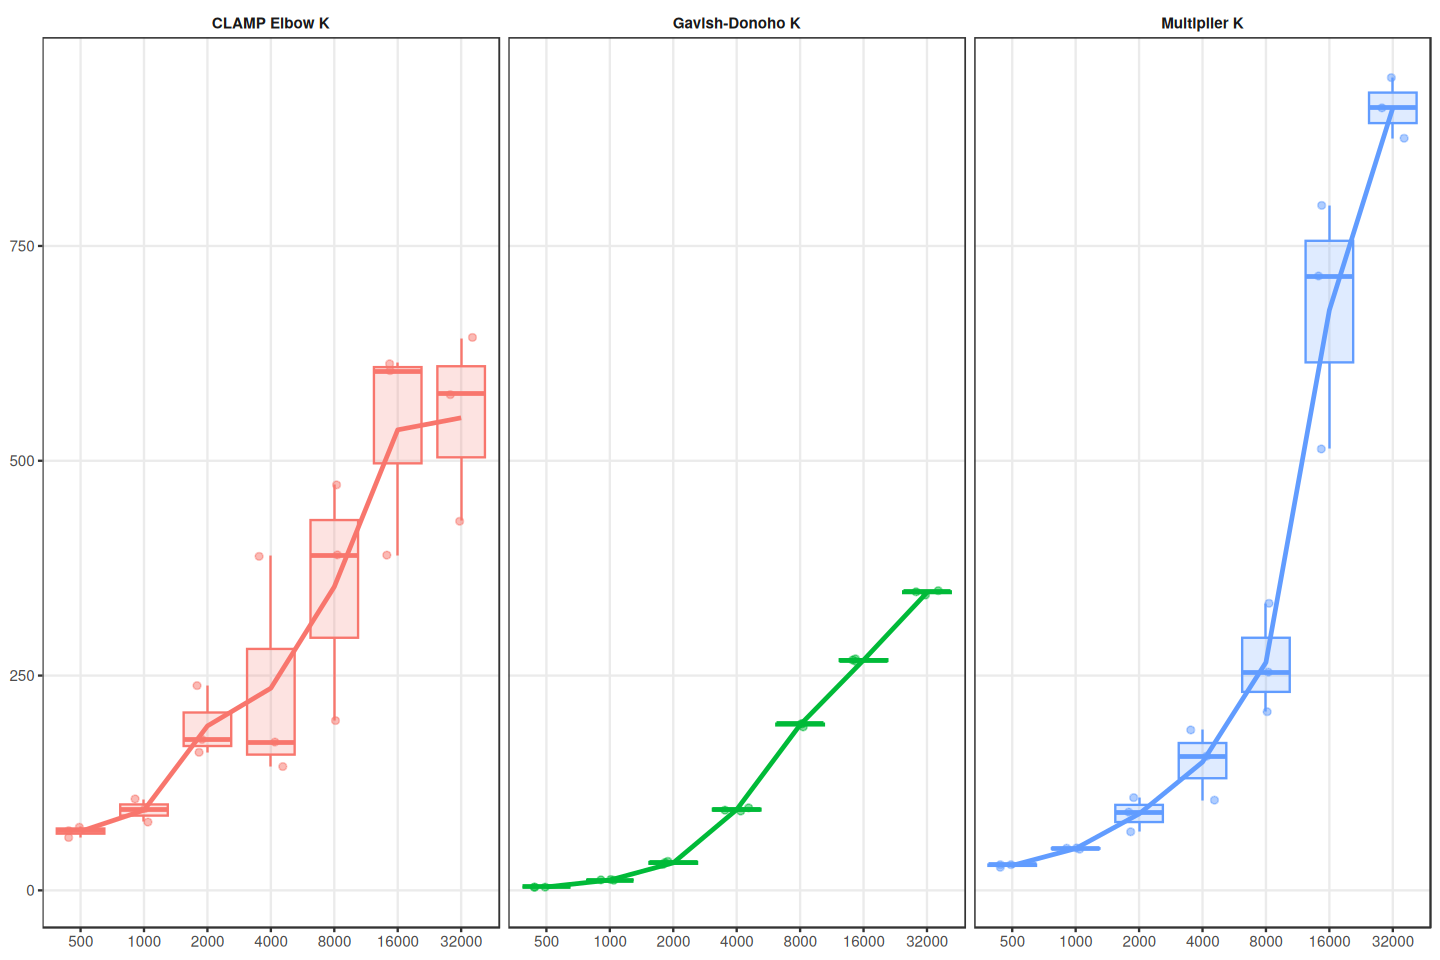

In [14]:
options(repr.plot.width = 12, repr.plot.height = 8)

plot_df <- reshape(
  results_df[, c("sample_size", "k_elbow_x2", "k_gavish_x2", "k_multiplier")],
  varying = c("k_elbow_x2", "k_gavish_x2", "k_multiplier"),
  v.names = "K_Estimate",
  timevar = "Method",
  times = c("k_elbow_x2", "k_gavish_x2", "k_multiplier"),
  direction = "long"
)

plot_df$Method <- factor(plot_df$Method, 
                         levels = c("k_elbow_x2", "k_gavish_x2", "k_multiplier"),
                         labels = c("CLAMP Elbow K", "Gavish-Donoho K", "Multiplier K"))

ggplot(plot_df, aes(x = factor(sample_size), y = K_Estimate, color = Method)) +
  geom_boxplot(aes(fill = Method), alpha = 0.2, outlier.shape = NA) +
  geom_point(position = position_jitter(width = 0.2), alpha = 0.5) +
  stat_summary(aes(group = 1), fun = mean, geom = "line", linewidth = 1) +
  facet_wrap(~Method) +
  theme_bw() +
  theme(
    legend.position = "none",
    axis.title = element_blank(),
    panel.grid.minor = element_blank(),
    strip.background = element_blank(),
    strip.text = element_text(face = "bold")
  )

## rsvd analyses

Same elbow and Gavish-Donoho analyses using `svd_rsvd.rds` (computed by
`12_rsvd_svd_computation.ipynb` with `rsvd::rsvd()`).
Results are stored in `results_rsvd_df` and compared with the `big_randomSVD` estimates below.

In [15]:
rows_rsvd <- list()

for (n_target in sample_sizes) {
  for (run_idx in seq_len(n_seeds)) {

    run_dir <- file.path(output_dir, paste0("c2cp_subsample_", n_target, "_seed_", run_idx))

    if (!dir.exists(run_dir)) {
      message("Skipping (not found): ", run_dir)
      next
    }

    svd_rsvd_path <- file.path(run_dir, "svd_rsvd.rds")
    if (!file.exists(svd_rsvd_path)) {
      message(sprintf("No svd_rsvd.rds — skipping n=%d run=%d", n_target, run_idx))
      next
    }

    message(sprintf("── n=%d  run=%d ──────────────────────────────", n_target, run_idx))

    # ── subsample info ─────────────────────────────────────
    info      <- readRDS(file.path(run_dir, "subsample_info.rds"))
    n_samples <- info$n_samples

    # ── Load rsvd SVD ──────────────────────────────────────
    svd_result   <- readRDS(svd_rsvd_path)
    n_components <- length(svd_result$d)
    d            <- svd_result$d
    n_genes      <- nrow(svd_result$u)
    rm(svd_result)

    # ── Load CLAMP K ───────────────────────────────────────
    k_multiplier <- readRDS(file.path(run_dir, "CLAMP_K.rds"))

    # ── 1. Elbow ───────────────────────────────────────────
    t_elbow <- system.time({ k_elbow <- CLAMP:::run_elbow(d) })["elapsed"]
    message(sprintf("  elbow:    k=%d  [%.2fs]", k_elbow, t_elbow))

    # ── 2. Gavish-Donoho ───────────────────────────────────
    t_gavish <- system.time({
      eigenvalues <- sort(d^2 / (n_samples - 1), decreasing = TRUE)
      noise_gd    <- median(eigenvalues)
      k_gavish    <- PCAtools::chooseGavishDonoho(
        .dim          = c(n_genes, n_samples),
        var.explained = eigenvalues,
        noise         = noise_gd
      )
    })["elapsed"]
    message(sprintf("  gavish:   k=%d  [%.2fs]", k_gavish, t_gavish))

    rows_rsvd[[length(rows_rsvd) + 1]] <- data.frame(
      sample_size  = n_target,
      run          = run_idx,
      seed         = info$seed,
      n_samples    = n_samples,
      n_components = n_components,
      k_elbow      = k_elbow,
      k_elbow_x2   = k_elbow * 2,
      k_gavish     = k_gavish,
      k_gavish_x2  = k_gavish * 2,
      k_multiplier = k_multiplier,
      t_elbow_s    = as.numeric(t_elbow),
      t_gavish_s   = as.numeric(t_gavish)
    )

    rm(d, eigenvalues)
    gc()
  }
}

results_rsvd_df <- dplyr::bind_rows(rows_rsvd)

── n=500  run=1 ──────────────────────────────

  elbow:    k=37  [0.00s]

  gavish:   k=2  [0.00s]

── n=500  run=2 ──────────────────────────────

  elbow:    k=33  [0.00s]

  gavish:   k=2  [0.00s]

── n=500  run=3 ──────────────────────────────

  elbow:    k=31  [0.00s]

  gavish:   k=2  [0.00s]

── n=1000  run=1 ──────────────────────────────

  elbow:    k=40  [0.00s]

  gavish:   k=6  [0.00s]

── n=1000  run=2 ──────────────────────────────

  elbow:    k=47  [0.00s]

  gavish:   k=6  [0.00s]

── n=1000  run=3 ──────────────────────────────

  elbow:    k=51  [0.00s]

  gavish:   k=6  [0.00s]

── n=2000  run=1 ──────────────────────────────

  elbow:    k=80  [0.00s]

  gavish:   k=17  [0.00s]

── n=2000  run=2 ──────────────────────────────

  elbow:    k=118  [0.00s]

  gavish:   k=16  [0.00s]

── n=2000  run=3 ──────────────────────────────

  elbow:    k=88  [0.00s]

  gavish:   k=17  [0.00s]

── n=4000  run=1 ──────────────────────────────

  elbow:    k=122  [0.00s]

  ga

In [16]:
results_rsvd_df <- results_rsvd_df %>%
  dplyr::left_join(
    archs4_k %>% dplyr::select(sample_size, seed, k_archs4),
    by = c("sample_size", "seed")
  )

message("rsvd rows with archs4 K matched: ",
        sum(!is.na(results_rsvd_df$k_archs4)), " / ", nrow(results_rsvd_df))

rsvd rows with archs4 K matched: 21 / 21



## rsvd results table

In [17]:
knitr::kable(
  results_rsvd_df %>% dplyr::select(
    sample_size, run,
    k_elbow_x2,
    k_gavish_x2,
    k_multiplier
  ),
  caption = "rsvd — K estimates (×2) by method vs CLAMP_K — recount2 subsamples"
)



Table: rsvd — K estimates (×2) by method vs CLAMP_K — recount2 subsamples

| sample_size| run| k_elbow_x2| k_gavish_x2| k_multiplier|
|-----------:|---:|----------:|-----------:|------------:|
|         500|   1|         74|           4|           30|
|         500|   2|         66|           4|           27|
|         500|   3|         62|           4|           30|
|        1000|   1|         80|          12|           48|
|        1000|   2|         94|          12|           49|
|        1000|   3|        102|          12|           49|
|        2000|   1|        160|          34|           68|
|        2000|   2|        236|          32|           91|
|        2000|   3|        176|          34|          108|
|        4000|   1|        244|          94|          187|
|        4000|   2|        144|          96|          105|
|        4000|   3|        172|          92|          156|
|        8000|   1|        472|         194|          254|
|        8000|   2|        198|       

## rsvd per-method plot

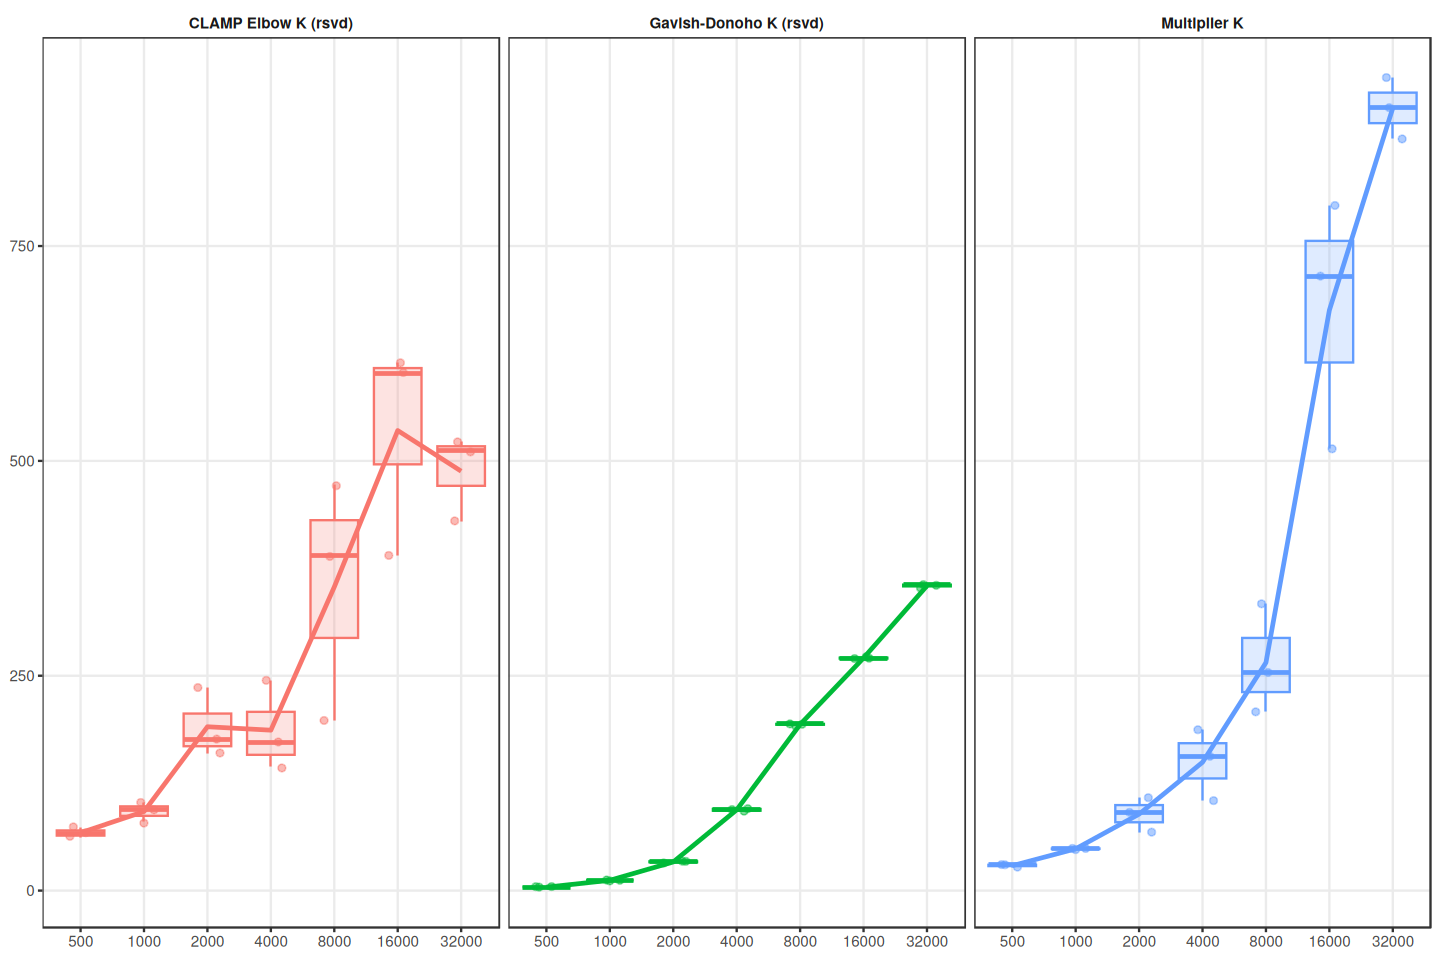

In [18]:
options(repr.plot.width = 12, repr.plot.height = 8)

plot_rsvd_df <- reshape(
  results_rsvd_df[, c("sample_size", "k_elbow_x2", "k_gavish_x2", "k_multiplier")],
  varying   = c("k_elbow_x2", "k_gavish_x2", "k_multiplier"),
  v.names   = "K_Estimate",
  timevar   = "Method",
  times     = c("k_elbow_x2", "k_gavish_x2", "k_multiplier"),
  direction = "long"
)

plot_rsvd_df$Method <- factor(
  plot_rsvd_df$Method,
  levels = c("k_elbow_x2", "k_gavish_x2", "k_multiplier"),
  labels = c("CLAMP Elbow K (rsvd)", "Gavish-Donoho K (rsvd)", "Multiplier K")
)

ggplot(plot_rsvd_df, aes(x = factor(sample_size), y = K_Estimate, color = Method)) +
  geom_boxplot(aes(fill = Method), alpha = 0.2, outlier.shape = NA) +
  geom_point(position = position_jitter(width = 0.2), alpha = 0.5) +
  stat_summary(aes(group = 1), fun = mean, geom = "line", linewidth = 1) +
  facet_wrap(~Method) +
  theme_bw() +
  theme(
    legend.position  = "none",
    axis.title       = element_blank(),
    panel.grid.minor = element_blank(),
    strip.background = element_blank(),
    strip.text       = element_text(face = "bold")
  )

## big_randomSVD vs rsvd comparison

Side-by-side comparison of elbow and Gavish-Donoho estimates from both SVD\nimplementations. Only rows present in both `results_df` and `results_rsvd_df`\nare included.

In [19]:
cmp_df <- dplyr::inner_join(
  results_df %>% dplyr::select(
    sample_size, run,
    k_elbow_x2_bigsvd  = k_elbow_x2,
    k_gavish_bigsvd    = k_gavish_x2,
    k_multiplier
  ),
  results_rsvd_df %>% dplyr::select(
    sample_size, run,
    k_elbow_x2_rsvd = k_elbow_x2,
    k_gavish_rsvd   = k_gavish_x2
  ),
  by = c("sample_size", "run")
)

knitr::kable(
  cmp_df,
  caption = "big_randomSVD vs rsvd — K estimates side by side"
)



Table: big_randomSVD vs rsvd — K estimates side by side

| sample_size| run| k_elbow_x2_bigsvd| k_gavish_bigsvd| k_multiplier| k_elbow_x2_rsvd| k_gavish_rsvd|
|-----------:|---:|-----------------:|---------------:|------------:|---------------:|-------------:|
|         500|   1|                74|               4|           30|              74|             4|
|         500|   2|                70|               4|           27|              66|             4|
|         500|   3|                62|               4|           30|              62|             4|
|        1000|   1|                80|              12|           48|              80|            12|
|        1000|   2|                94|              12|           49|              94|            12|
|        1000|   3|               106|              12|           49|             102|            12|
|        2000|   1|               160|              32|           68|             160|            34|
|        2000|   2|    

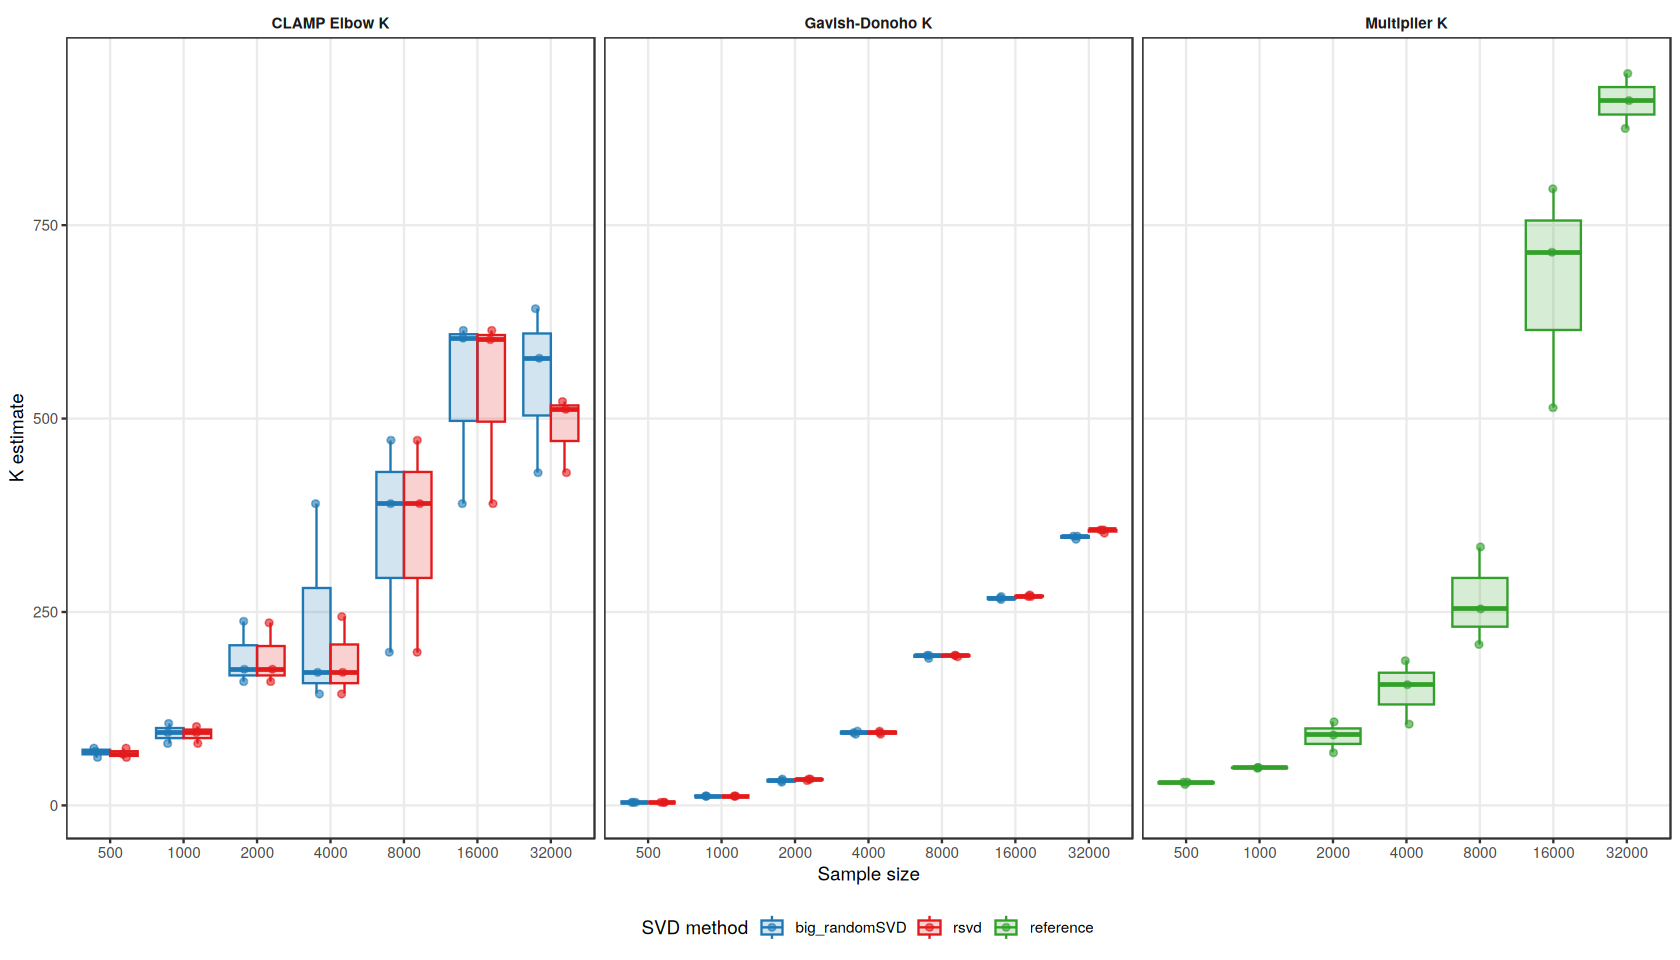

In [20]:
options(repr.plot.width = 14, repr.plot.height = 8)

# Build long-format data combining both SVD implementations
long_cmp <- rbind(
  data.frame(
    sample_size = results_df$sample_size,
    svd_method  = "big_randomSVD",
    Method      = "CLAMP Elbow K",
    K_Estimate  = results_df$k_elbow_x2
  ),
  data.frame(
    sample_size = results_df$sample_size,
    svd_method  = "big_randomSVD",
    Method      = "Gavish-Donoho K",
    K_Estimate  = results_df$k_gavish_x2
  ),
  data.frame(
    sample_size = results_rsvd_df$sample_size,
    svd_method  = "rsvd",
    Method      = "CLAMP Elbow K",
    K_Estimate  = results_rsvd_df$k_elbow_x2
  ),
  data.frame(
    sample_size = results_rsvd_df$sample_size,
    svd_method  = "rsvd",
    Method      = "Gavish-Donoho K",
    K_Estimate  = results_rsvd_df$k_gavish_x2
  ),
  data.frame(
    sample_size = results_df$sample_size,
    svd_method  = "reference",
    Method      = "Multiplier K",
    K_Estimate  = results_df$k_multiplier
  )
)

long_cmp$svd_method <- factor(long_cmp$svd_method,
                               levels = c("big_randomSVD", "rsvd", "reference"))

ggplot(long_cmp, aes(x = factor(sample_size), y = K_Estimate,
                     color = svd_method, fill = svd_method)) +
  geom_boxplot(alpha = 0.2, outlier.shape = NA,
               position = position_dodge(width = 0.75)) +
  geom_point(position = position_jitterdodge(jitter.width = 0.15, dodge.width = 0.75),
             alpha = 0.6, size = 1.5) +
  facet_wrap(~Method, scales = "fixed") +
  scale_color_manual(values = c("big_randomSVD" = "#1f78b4",
                                "rsvd"          = "#e31a1c",
                                "reference"     = "#33a02c")) +
  scale_fill_manual(values  = c("big_randomSVD" = "#1f78b4",
                                "rsvd"          = "#e31a1c",
                                "reference"     = "#33a02c")) +
  labs(color = "SVD method", fill = "SVD method",
       x = "Sample size", y = "K estimate") +
  theme_bw() +
  theme(
    panel.grid.minor = element_blank(),
    strip.background = element_blank(),
    strip.text       = element_text(face = "bold"),
    legend.position  = "bottom"
  )

## Eigenvalue scatterplot: big_randomSVD vs rsvd

For each subsample, paired singular values are aligned by rank index and
converted to eigenvalues (`d² / (n_samples − 1)`).
Only the `min(length(d_bigsvd), length(d_rsvd))` shared ranks are plotted.
A perfect match between implementations would fall on the identity line (dashed).

In [21]:
ev_rows <- list()

for (n_target in sample_sizes) {
  for (run_idx in seq_len(n_seeds)) {

    run_dir <- file.path(output_dir, paste0("c2cp_subsample_", n_target, "_seed_", run_idx))

    bigsvd_path <- file.path(run_dir, "svd.rds")
    rsvd_path   <- file.path(run_dir, "svd_rsvd.rds")

    if (!file.exists(bigsvd_path) || !file.exists(rsvd_path)) next

    info      <- readRDS(file.path(run_dir, "subsample_info.rds"))
    n_samples <- info$n_samples

    d_big  <- readRDS(bigsvd_path)$d
    d_rsvd <- readRDS(rsvd_path)$d

    n_shared <- min(length(d_big), length(d_rsvd))
    d_big    <- d_big[seq_len(n_shared)]
    d_rsvd   <- d_rsvd[seq_len(n_shared)]

    ev_rows[[length(ev_rows) + 1]] <- data.frame(
      sample_size   = n_target,
      sample_size_f = factor(n_target),
      run           = run_idx,
      rank          = seq_len(n_shared),
      ev_bigsvd     = d_big^2  / (n_samples - 1),
      ev_rsvd       = d_rsvd^2 / (n_samples - 1)
    )
  }
}

ev_df <- dplyr::bind_rows(ev_rows)
ev_df$sample_size_f <- factor(ev_df$sample_size_f,
                               levels = as.character(sort(sample_sizes)))
message("ev_df rows: ", nrow(ev_df))

ev_df rows: 19104



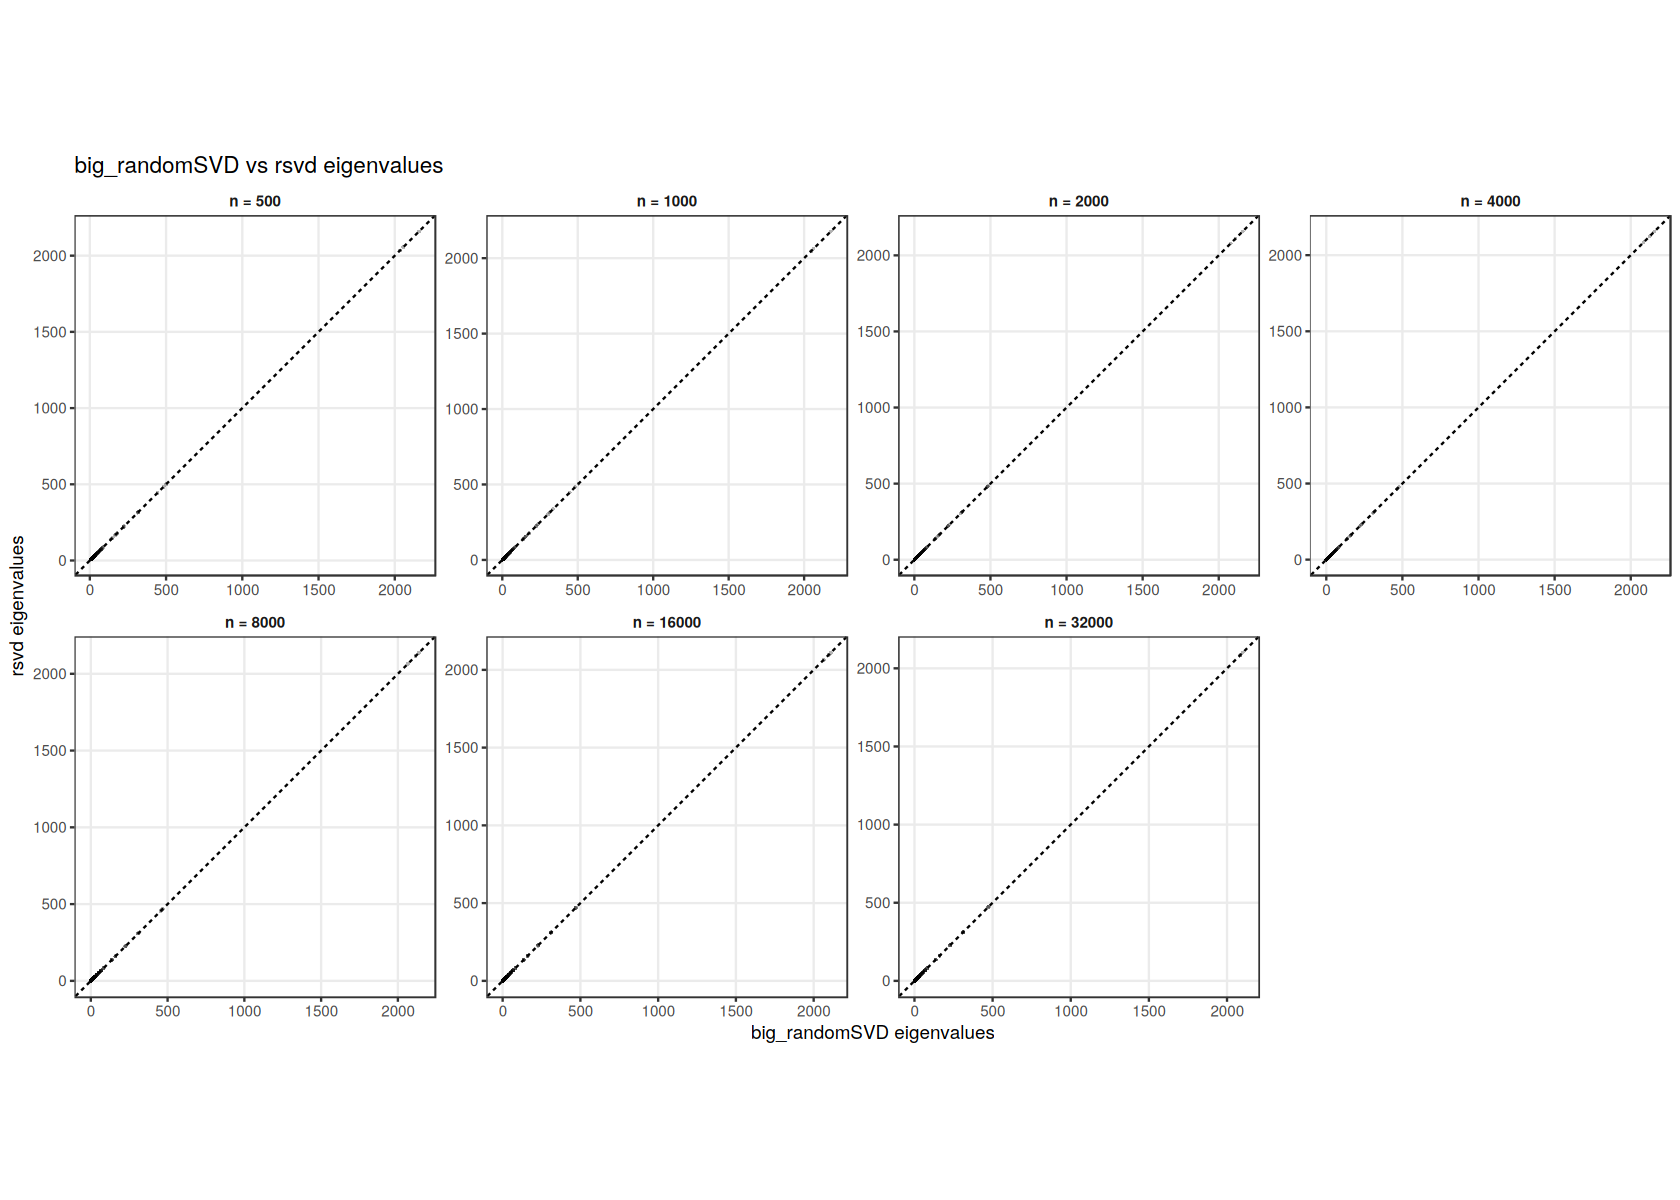

In [22]:
options(repr.plot.width = 14, repr.plot.height = 10)

ggplot(ev_df, aes(x = ev_bigsvd, y = ev_rsvd)) +
  geom_point(alpha = 0.3, size = 0.5, shape = 16) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", linewidth = 0.5, color = "black") +
  facet_wrap(~sample_size_f, scales = "free", ncol = 4,
             labeller = labeller(sample_size_f = function(x) paste0("n = ", x))) +
  labs(
    x = "big_randomSVD eigenvalues",
    y = "rsvd eigenvalues",
    title = "big_randomSVD vs rsvd eigenvalues"
  ) +
  theme_bw() +
  theme(
    panel.grid.minor = element_blank(),
    strip.background = element_blank(),
    strip.text       = element_text(face = "bold"),
    aspect.ratio     = 1
  )

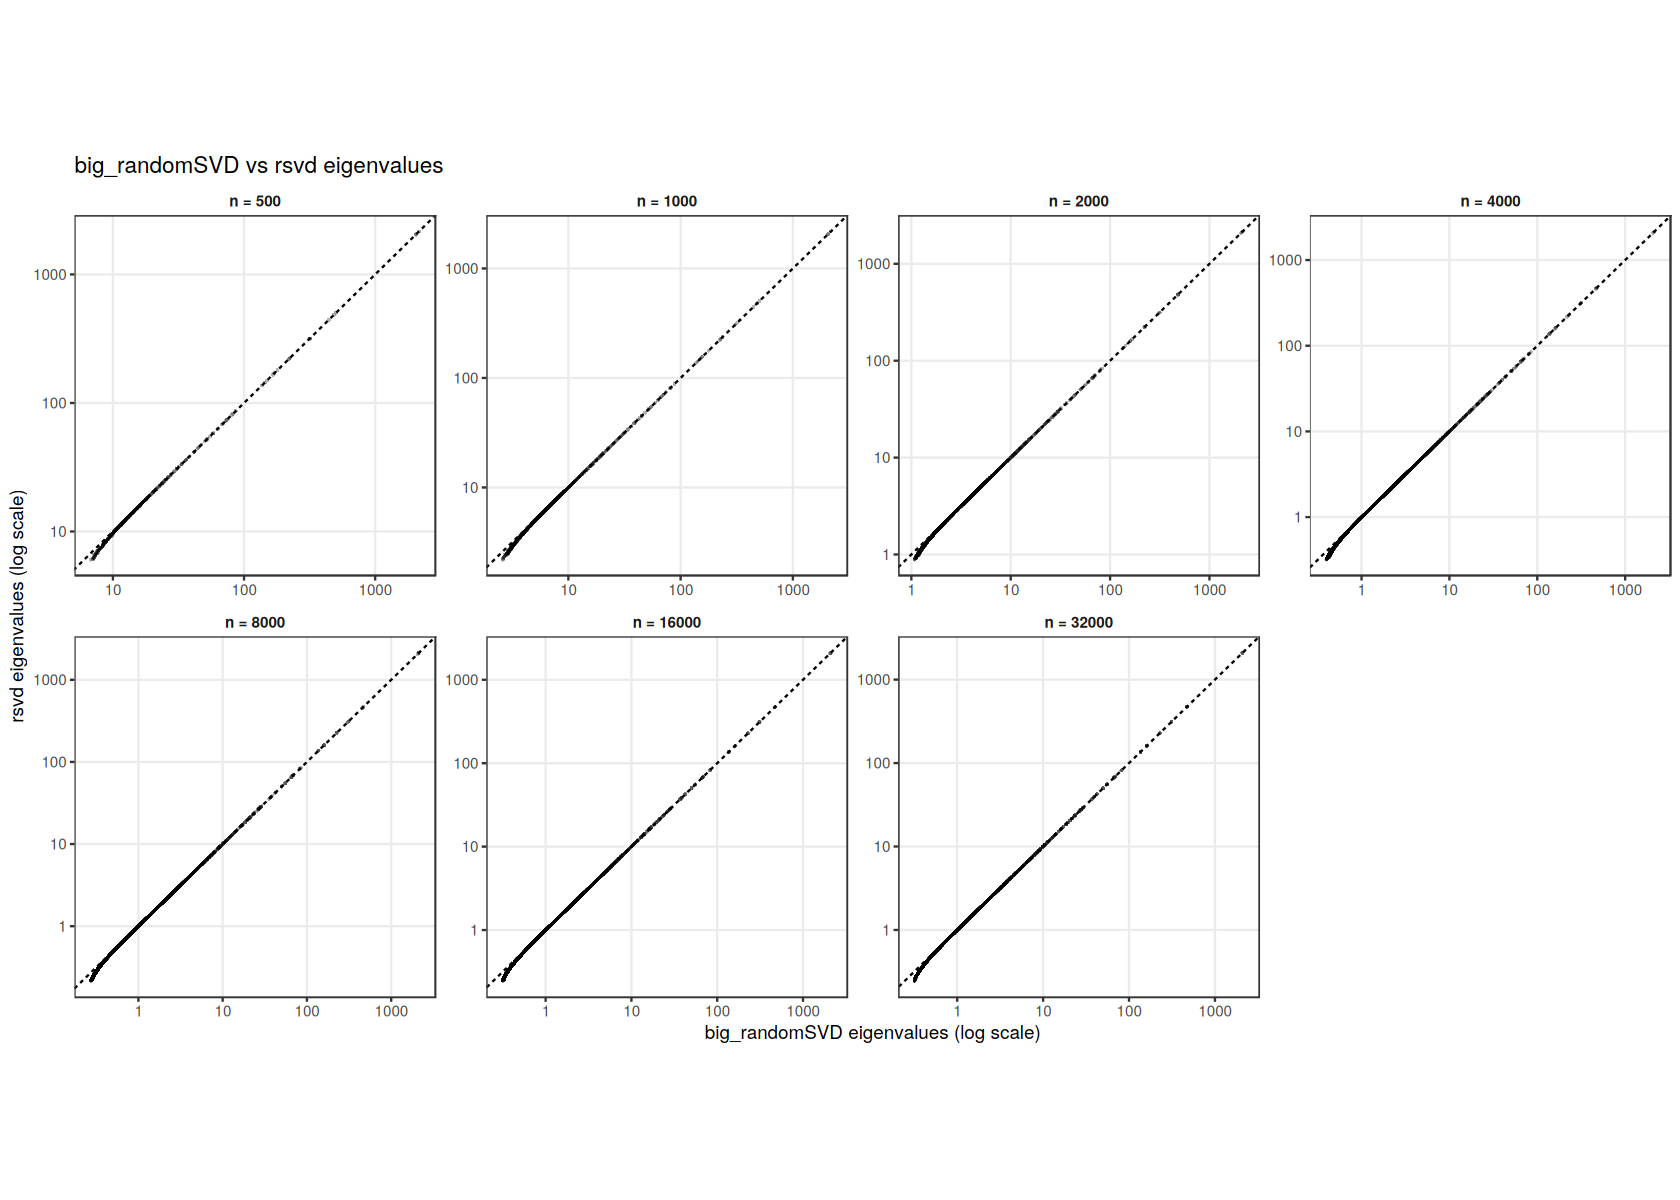

In [23]:
options(repr.plot.width = 14, repr.plot.height = 10)

ggplot(ev_df, aes(x = ev_bigsvd, y = ev_rsvd)) +
  geom_point(alpha = 0.3, size = 0.5, shape = 16) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", linewidth = 0.5, color = "black") +
  facet_wrap(~sample_size_f, scales = "free", ncol = 4,
             labeller = labeller(sample_size_f = function(x) paste0("n = ", x))) +
  scale_x_log10() +
  scale_y_log10() +
  labs(
    x = "big_randomSVD eigenvalues (log scale)",
    y = "rsvd eigenvalues (log scale)",
    title = "big_randomSVD vs rsvd eigenvalues"
  ) +
  theme_bw() +
  theme(
    panel.grid.minor = element_blank(),
    strip.background = element_blank(),
    strip.text       = element_text(face = "bold"),
    aspect.ratio     = 1
  )

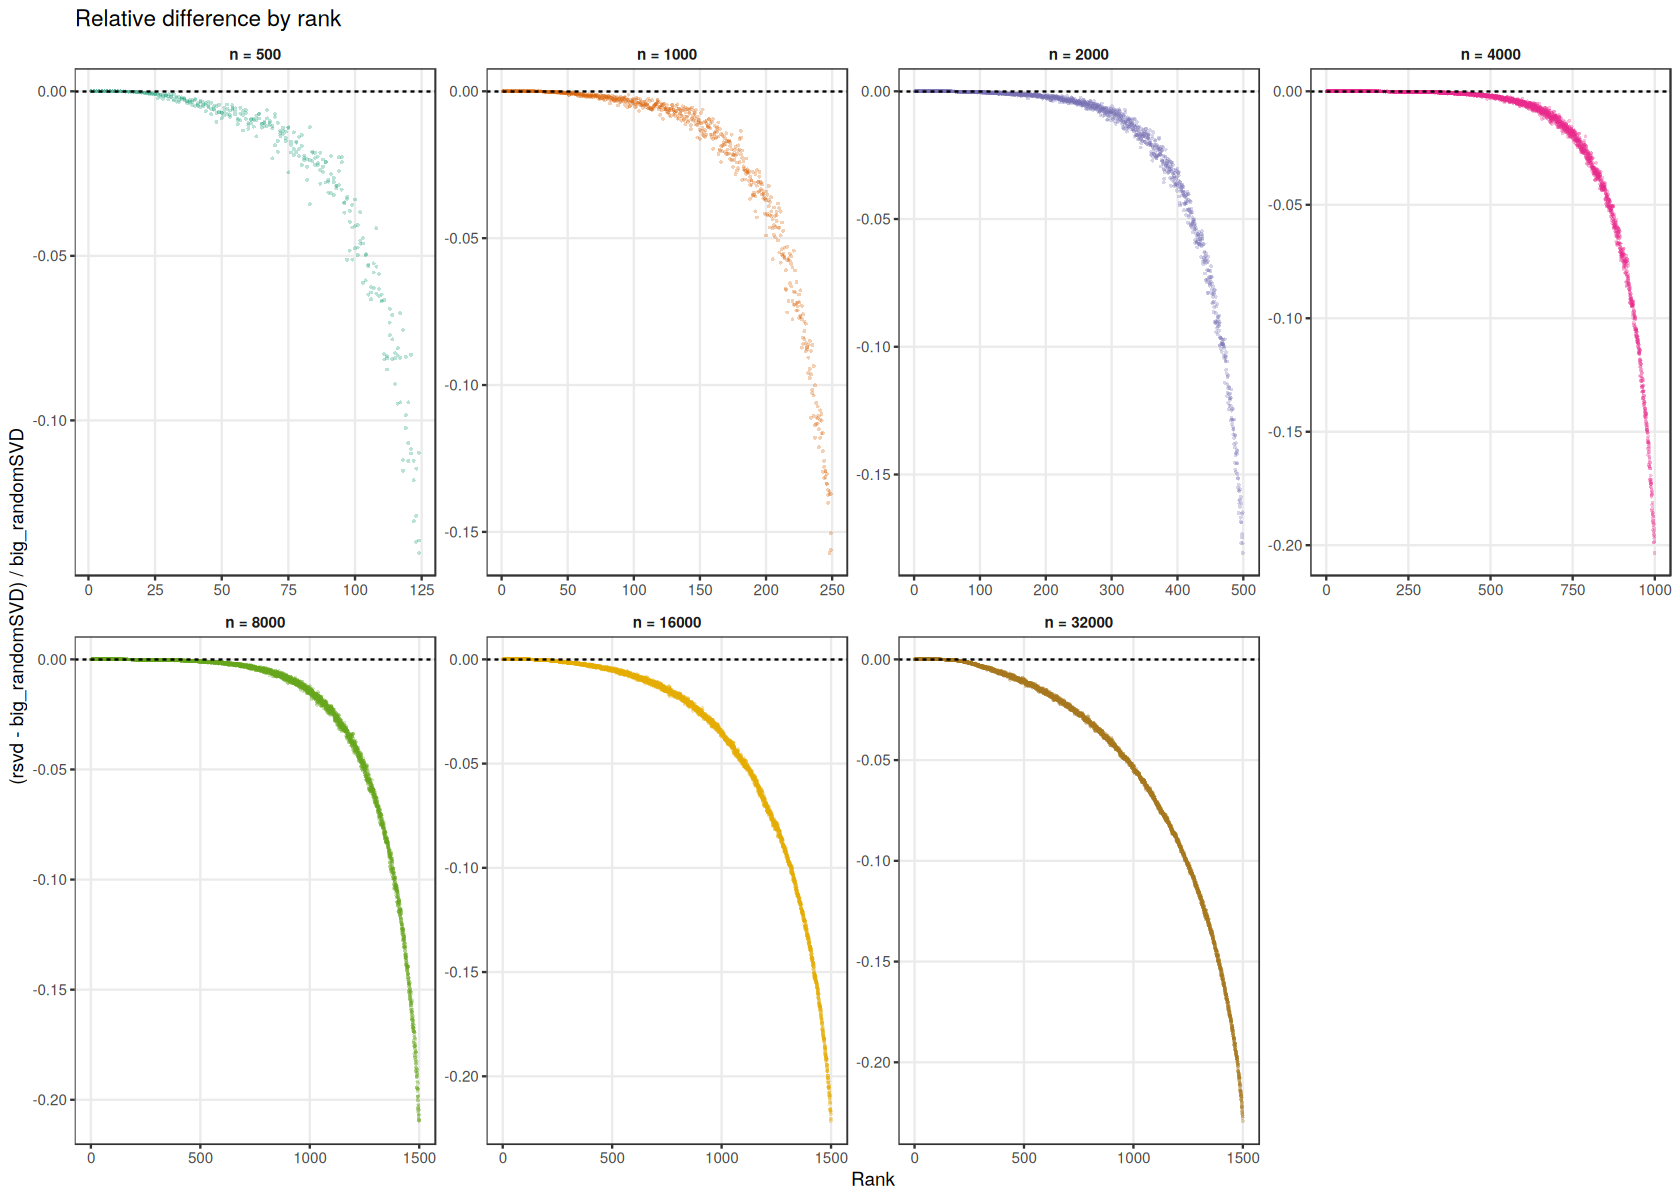

In [24]:
options(repr.plot.width = 14, repr.plot.height = 10)

ev_df$rel_diff <- (ev_df$ev_rsvd - ev_df$ev_bigsvd) / (ev_df$ev_bigsvd + 1e-30)

ggplot(ev_df, aes(x = rank, y = rel_diff, color = sample_size_f)) +
  geom_point(alpha = 0.3, size = 0.5, shape = 16) +
  geom_hline(yintercept = 0, linetype = "dashed", linewidth = 0.5, color = "black") +
  facet_wrap(~sample_size_f, scales = "free", ncol = 4,
             labeller = labeller(sample_size_f = function(x) paste0("n = ", x))) +
  scale_color_brewer(palette = "Dark2") +
  labs(
    x = "Rank",
    y = "(rsvd - big_randomSVD) / big_randomSVD",
    title = "Relative difference by rank"
  ) +
  theme_bw() +
  theme(
    legend.position  = "none",
    panel.grid.minor = element_blank(),
    strip.background = element_blank(),
    strip.text       = element_text(face = "bold")
  )

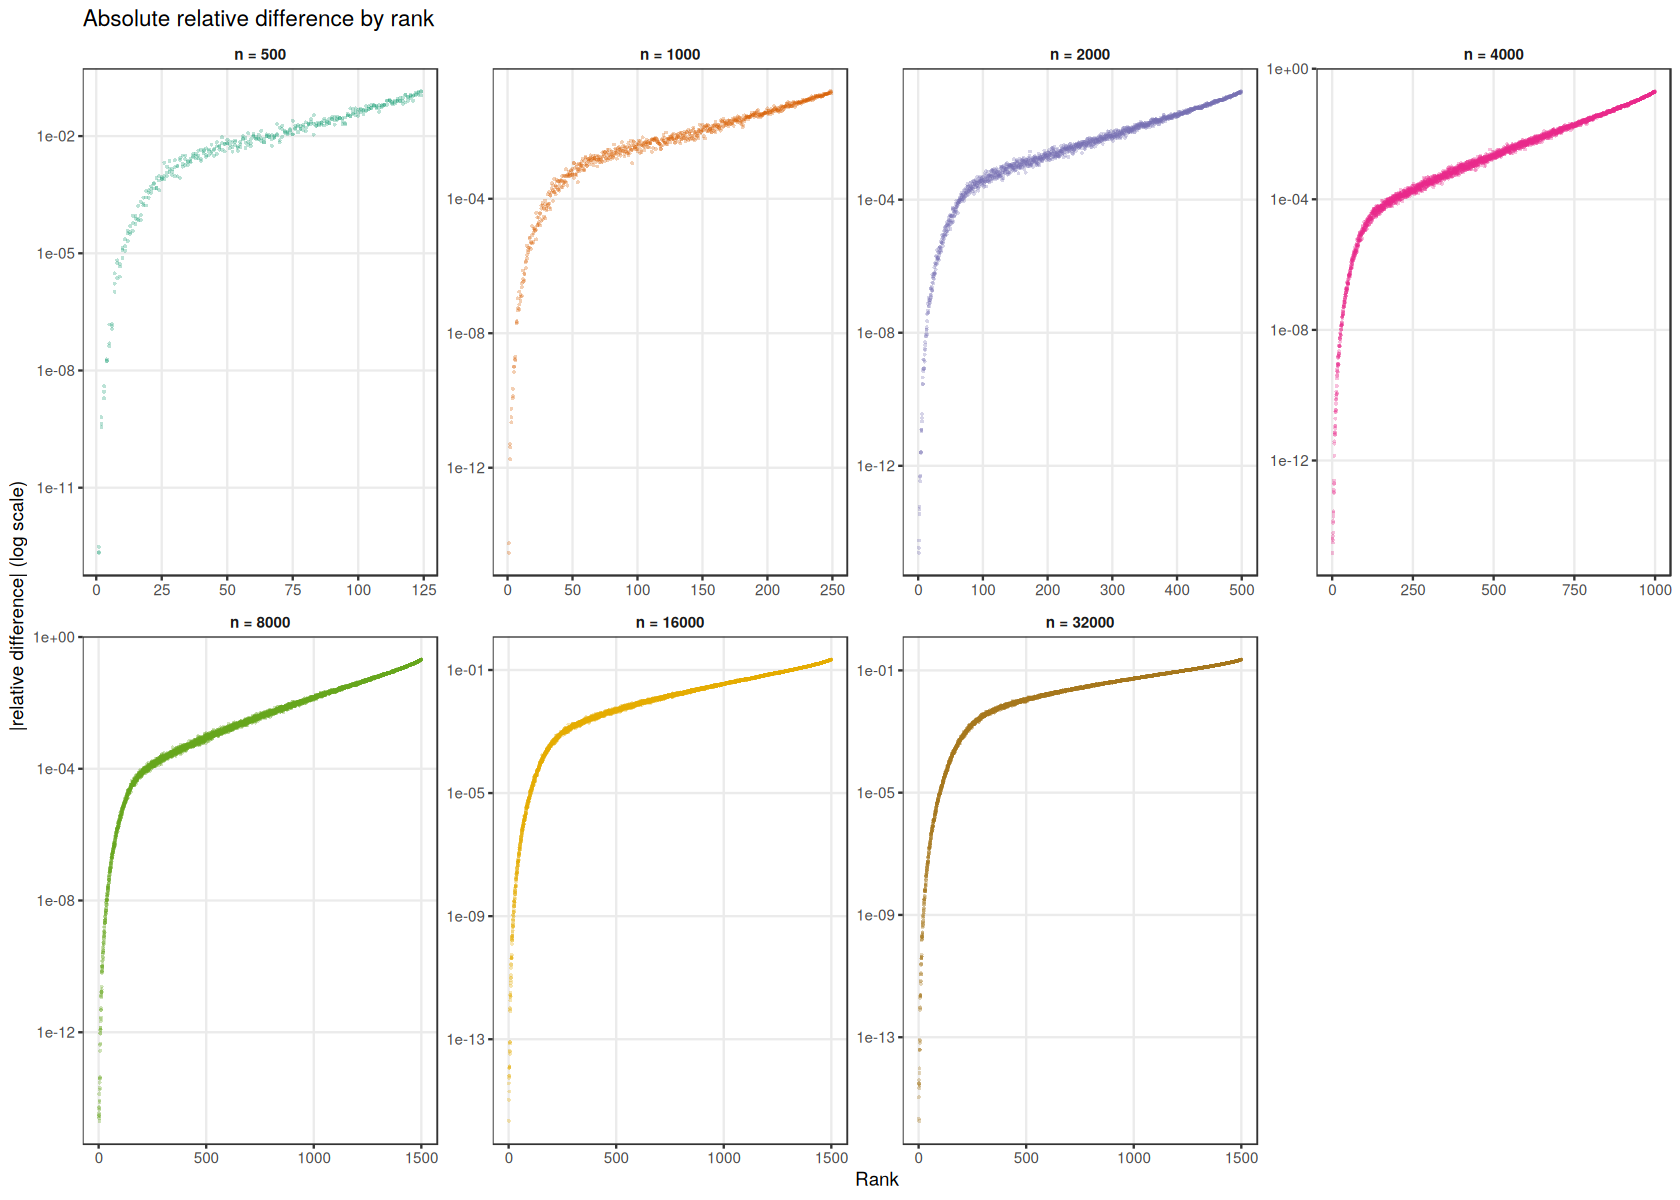

In [25]:
options(repr.plot.width = 14, repr.plot.height = 10)

ev_df$abs_rel_diff <- abs((ev_df$ev_rsvd - ev_df$ev_bigsvd) / (ev_df$ev_bigsvd + 1e-30))

ggplot(ev_df %>% filter(abs_rel_diff > 0), aes(x = rank, y = abs_rel_diff, color = sample_size_f)) +
  geom_point(alpha = 0.3, size = 0.5, shape = 16) +
  facet_wrap(~sample_size_f, scales = "free", ncol = 4,
             labeller = labeller(sample_size_f = function(x) paste0("n = ", x))) +
  scale_y_log10() +
  scale_color_brewer(palette = "Dark2") +
  labs(
    x = "Rank",
    y = "|relative difference| (log scale)",
    title = "Absolute relative difference by rank"
  ) +
  theme_bw() +
  theme(
    legend.position  = "none",
    panel.grid.minor = element_blank(),
    strip.background = element_blank(),
    strip.text       = element_text(face = "bold")
  )